# 🎓 Smart Career Path Recommendation — Model Training Notebook

**Project:** Smart Career Path Recommendation System for Nigerian Secondary School Students  
**Classes:** JSS 2, JSS 3, SSS 1, SSS 2  
**Data source:** Synthetic dataset grounded in Nigerian NERDC curriculum & WAEC grading bands  
**Models:** Random Forest (baseline) + XGBoost (primary)  
**Target:** 10 Nigerian career path labels

---

## Folder structure expected
```
project/
├── app.py                     ← Streamlit app
├── train_model.ipynb          ← This notebook
├── data/
│   └── nigerian_career_dataset.csv
└── ml/
    └── models/                ← Trained .pkl files saved here
```


## 1. Install & Import Libraries

In [2]:
# Run once if needed
# !pip install xgboost lightgbm scikit-learn pandas numpy joblib matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, accuracy_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

os.makedirs("ml/models", exist_ok=True)
print("✅ All libraries imported.")


✅ All libraries imported.


## 2. Load & Inspect Dataset

In [3]:
df = pd.read_csv("data/nigerian_career_dataset.csv")
df = df.fillna(0)   # NaN = subject not offered at that class level → 0

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nCareer label distribution:")
print(df["career_path"].value_counts())
print(f"\nClass level distribution:")
print(df["class_level"].value_counts())
print(f"\nDepartment distribution (SSS only):")
print(df[df["class_level"].isin(["SSS1","SSS2"])]["department"].value_counts())
df.head(10)


Shape: 2800 rows × 108 columns

Career label distribution:
career_path
Creative Arts & Design                  456
Entrepreneurship & Management           319
Business & Finance                      280
Education & Humanities                  264
Agriculture & Environmental Sciences    263
Law & Social Sciences                   259
Mass Communication & Media              258
Medicine & Health Sciences              246
Computer Science & IT                   238
Engineering & Technology                217
Name: count, dtype: int64

Class level distribution:
class_level
SSS1    1050
SSS2    1050
JSS2     350
JSS3     350
Name: count, dtype: int64

Department distribution (SSS only):
department
Science       700
Arts          700
Commercial    700
Name: count, dtype: int64


,student_id,class_level,department,strength_level,term1_avg,term2_avg,term3_avg,session_avg,consistency_score,performance_trend,...,t1_Office_Practice,t1_Insurance,t2_Accounting,t2_Commerce,t2_Office_Practice,t2_Insurance,t3_Accounting,t3_Commerce,t3_Office_Practice,t3_Insurance
0,1,JSS2,N_A,average,62.93,61.57,63.95,62.82,98.05,Stable,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,JSS2,N_A,average,66.43,71.51,63.11,67.02,93.09,Stable,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,JSS2,N_A,average,67.13,63.33,64.77,65.08,96.87,Stable,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,JSS2,N_A,high,74.77,77.35,80.03,77.38,95.70,Improving,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,JSS2,N_A,average,65.62,68.30,69.57,67.83,96.71,Stable,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,6,JSS2,N_A,average,62.02,60.78,59.15,60.65,97.65,Stable,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,7,JSS2,N_A,high,73.86,77.19,78.96,76.67,95.77,Improving,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,8,JSS2,N_A,average,65.52,62.73,60.17,62.81,95.63,Declining,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,9,JSS2,N_A,average,61.01,72.05,61.26,64.77,89.71,Stable,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,10,JSS2,N_A,average,64.65,60.96,57.70,61.10,94.32,Declining,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Exploratory Data Analysis

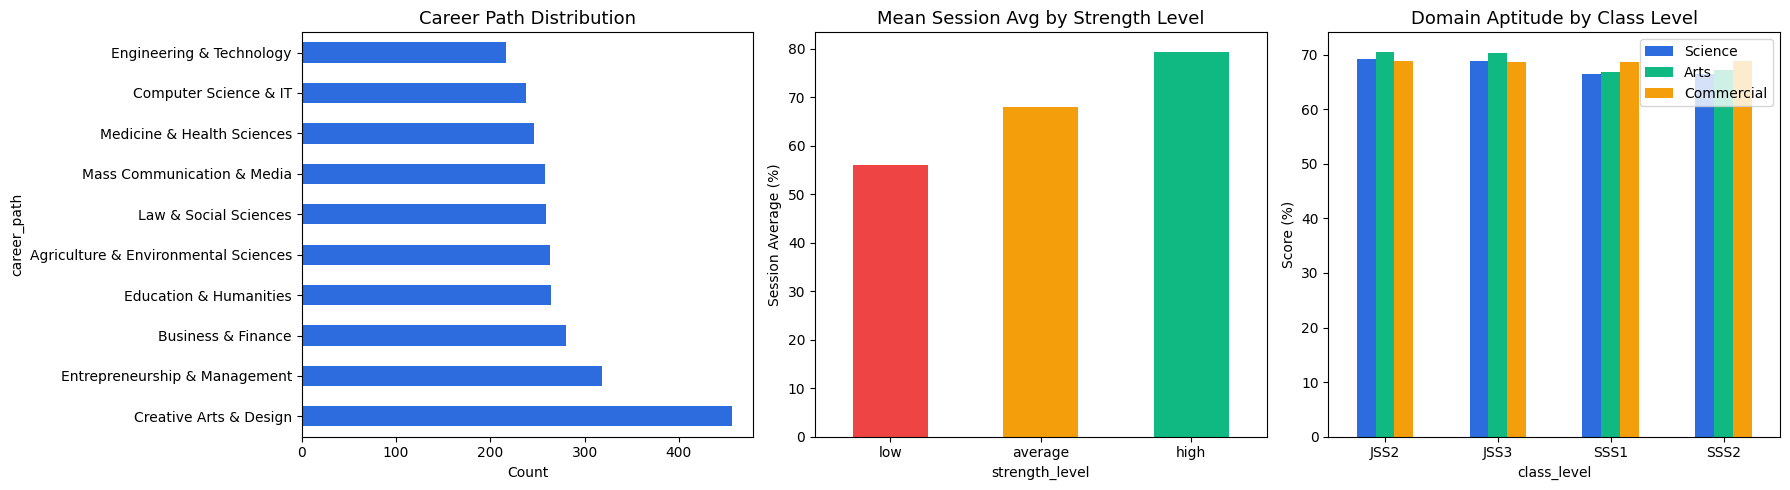

✅ EDA plots saved.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Career distribution
df["career_path"].value_counts().plot(kind="barh", ax=axes[0], color="#2d6cdf")
axes[0].set_title("Career Path Distribution", fontsize=13)
axes[0].set_xlabel("Count")

# Session average by strength level
df.groupby("strength_level")["session_avg"].mean().sort_values().plot(
    kind="bar", ax=axes[1], color=["#ef4444","#f59e0b","#10b981"])
axes[1].set_title("Mean Session Avg by Strength Level", fontsize=13)
axes[1].set_ylabel("Session Average (%)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Domain aptitude by class level
domain_cols = ["science_aptitude_score","arts_aptitude_score","commercial_aptitude_score"]
df.groupby("class_level")[domain_cols].mean().plot(kind="bar", ax=axes[2], 
    color=["#2d6cdf","#10b981","#f59e0b"])
axes[2].set_title("Domain Aptitude by Class Level", fontsize=13)
axes[2].set_ylabel("Score (%)")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(["Science", "Arts", "Commercial"])

plt.tight_layout()
plt.savefig("ml/models/eda_plots.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ EDA plots saved.")


## 4. Feature Engineering & Encoding

In [5]:
# ── Encode all categorical columns ──────────────────────────────────────────
CAT_COLS = ["class_level", "department", "strength_level",
            "performance_trend", "best_subject", "weak_subject"]

encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    joblib.dump(le, f"ml/models/le_{col}.pkl")
    print(f"  Saved encoder: le_{col}.pkl  |  classes: {list(le.classes_)}")

# ── Encode target ────────────────────────────────────────────────────────────
le_career = LabelEncoder()
y = le_career.fit_transform(df["career_path"])
joblib.dump(le_career, "ml/models/le_career.pkl")
print(f"\n  Target encoder saved. Career classes ({len(le_career.classes_)}):")
for i, c in enumerate(le_career.classes_):
    print(f"    {i}: {c}")


  Saved encoder: le_class_level.pkl  |  classes: ['JSS2', 'JSS3', 'SSS1', 'SSS2']
  Saved encoder: le_department.pkl  |  classes: ['Arts', 'Commercial', 'N_A', 'Science']
  Saved encoder: le_strength_level.pkl  |  classes: ['average', 'high', 'low']
  Saved encoder: le_performance_trend.pkl  |  classes: ['Declining', 'Improving', 'Stable']
  Saved encoder: le_best_subject.pkl  |  classes: ['Accounting', 'Agricultural_Science', 'Basic_Science', 'Biology', 'Business_Studies', 'CRS_IRK', 'Chemistry', 'Civic_Education', 'Commerce', 'Computer_Science', 'Computer_Studies', 'Cultural_and_Creative_Arts', 'Economics', 'English_Language', 'French', 'Further_Mathematics', 'Geography', 'Government', 'History', 'Home_Economics', 'Insurance', 'Literature_in_English', 'Mathematics', 'Office_Practice', 'Physical_Education', 'Physics', 'Social_Studies', 'Yoruba_Hausa_Igbo']
  Saved encoder: le_weak_subject.pkl  |  classes: ['Accounting', 'Agricultural_Science', 'Basic_Science', 'Biology', 'Business_Stu

## 5. Build Feature Matrix

In [6]:
# Drop raw categorical columns (encoded versions are kept)
DROP_COLS = ["student_id", "career_path"] + CAT_COLS

X = df.drop(columns=DROP_COLS).values   # numpy array — avoids sklearn feature-name warnings
feature_names = list(df.drop(columns=DROP_COLS).columns)

joblib.dump(feature_names, "ml/models/feature_names.pkl")
print(f"Feature matrix shape: {X.shape}")
print(f"Saved feature_names.pkl ({len(feature_names)} features)")
print(f"\nFirst 10 features: {feature_names[:10]}")


Feature matrix shape: (2800, 106)
Saved feature_names.pkl (106 features)

First 10 features: ['term1_avg', 'term2_avg', 'term3_avg', 'session_avg', 'consistency_score', 't1_Mathematics', 't1_English_Language', 't1_Basic_Science', 't1_Social_Studies', 't1_Civic_Education']


## 6. Scale Features & Train/Test Split

In [7]:
# ── Scale ────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, "ml/models/scaler.pkl")
print("✅ StandardScaler fitted and saved.")

# ── 80/20 stratified split ───────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y)

print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Class balance in train:")
unique, counts = np.unique(y_train, return_counts=True)
for i, c in zip(unique, counts):
    print(f"  {le_career.inverse_transform([i])[0]}: {c}")


✅ StandardScaler fitted and saved.

Train size: 2240 | Test size: 560
Class balance in train:
  Agriculture & Environmental Sciences: 211
  Business & Finance: 224
  Computer Science & IT: 190
  Creative Arts & Design: 365
  Education & Humanities: 211
  Engineering & Technology: 174
  Entrepreneurship & Management: 255
  Law & Social Sciences: 207
  Mass Communication & Media: 206
  Medicine & Health Sciences: 197


## 7. Baseline Model — Random Forest

In [8]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=18,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
joblib.dump(rf, "ml/models/rf_model.pkl")
print(f"✅ Random Forest  →  Test Accuracy: {rf_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf.predict(X_test), target_names=le_career.classes_))


✅ Random Forest  →  Test Accuracy: 86.96%

Classification Report:
                                      precision    recall  f1-score   support

Agriculture & Environmental Sciences       0.94      0.96      0.95        52
                  Business & Finance       0.84      0.93      0.88        56
               Computer Science & IT       0.76      0.85      0.80        48
              Creative Arts & Design       0.96      0.93      0.94        91
              Education & Humanities       0.82      0.89      0.85        53
            Engineering & Technology       0.82      0.72      0.77        43
       Entrepreneurship & Management       0.90      0.84      0.87        64
               Law & Social Sciences       0.81      0.83      0.82        52
          Mass Communication & Media       0.87      0.77      0.82        52
          Medicine & Health Sciences       0.92      0.90      0.91        49

                            accuracy                           0.87       

## Visualize Classification Report

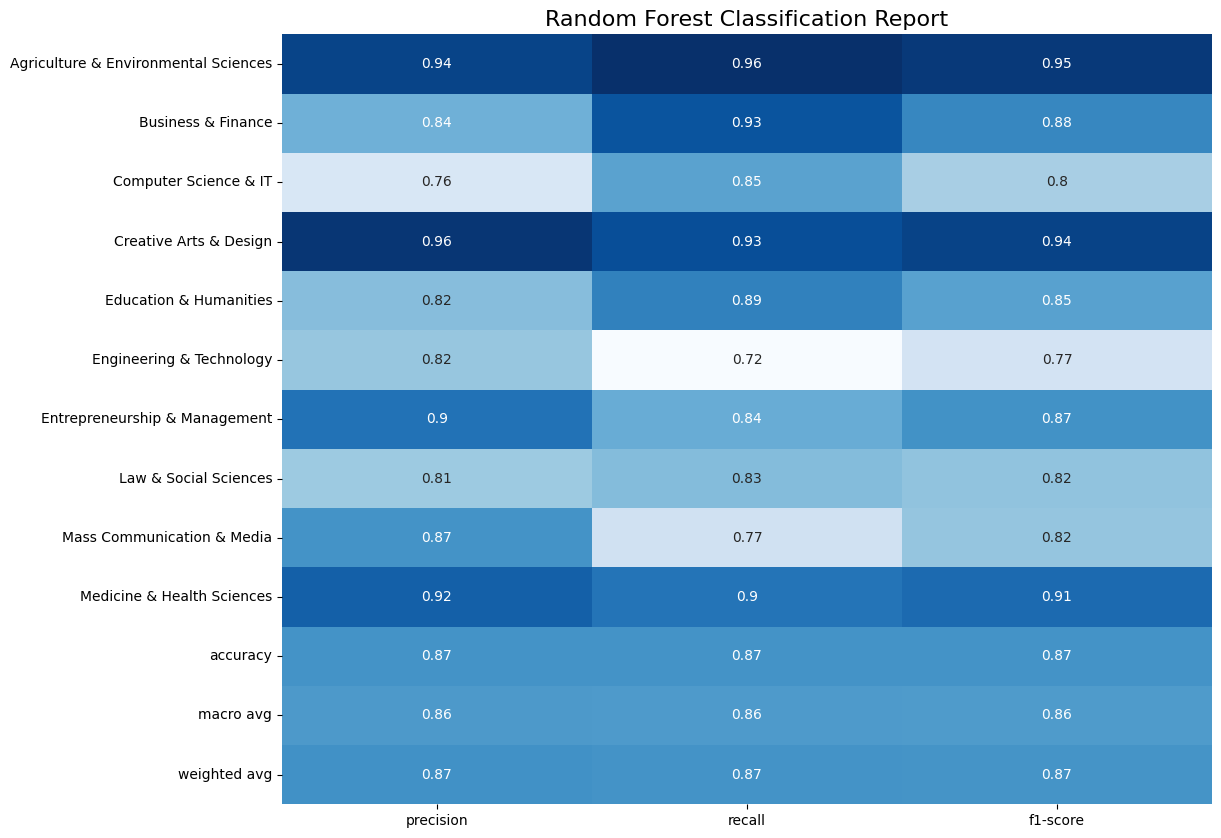

In [9]:
rf_classification_report = classification_report(y_test, rf.predict(X_test), target_names=le_career.classes_, output_dict=True)
with open("ml/models/classification_report.json", "w") as f:
    json.dump(rf_classification_report, f, indent=4)

# Plot Random Forest Classification Report
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pd.DataFrame(rf_classification_report).iloc[:-1, :].T, annot=True, cmap="Blues", cbar=False, ax=ax)
ax.set_title("Random Forest Classification Report", fontsize=16)
#plt.savefig("ml/models/classification_report.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Primary Model — XGBoost

In [10]:
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.80,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
xgb_acc = accuracy_score(y_test, xgb.predict(X_test))
joblib.dump(xgb, "ml/models/xgb_model.pkl")
print(f"✅ XGBoost  →  Test Accuracy: {xgb_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, xgb.predict(X_test), target_names=le_career.classes_))


✅ XGBoost  →  Test Accuracy: 88.21%

Classification Report:
                                      precision    recall  f1-score   support

Agriculture & Environmental Sciences       0.95      1.00      0.97        52
                  Business & Finance       0.84      0.84      0.84        56
               Computer Science & IT       0.84      0.85      0.85        48
              Creative Arts & Design       0.92      0.95      0.93        91
              Education & Humanities       0.89      0.89      0.89        53
            Engineering & Technology       0.77      0.77      0.77        43
       Entrepreneurship & Management       0.85      0.86      0.85        64
               Law & Social Sciences       0.89      0.96      0.93        52
          Mass Communication & Media       0.91      0.77      0.83        52
          Medicine & Health Sciences       0.93      0.88      0.91        49

                            accuracy                           0.88       560
  

## 9. Cross-Validation & Model Comparison

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv  = cross_val_score(rf,  X_scaled, y, cv=cv, scoring="accuracy", n_jobs=-1)
xgb_cv = cross_val_score(xgb, X_scaled, y, cv=cv, scoring="accuracy", n_jobs=-1)

print(f"Random Forest  CV: {rf_cv.mean()*100:.2f}% ± {rf_cv.std()*100:.2f}%")
print(f"XGBoost        CV: {xgb_cv.mean()*100:.2f}% ± {xgb_cv.std()*100:.2f}%")

# Save benchmark
benchmark = {
    "random_forest": {
        "test_accuracy": round(rf_acc*100, 2),
        "cv_mean": round(rf_cv.mean()*100, 2),
        "cv_std":  round(rf_cv.std()*100, 2)
    },
    "xgboost": {
        "test_accuracy": round(xgb_acc*100, 2),
        "cv_mean": round(xgb_cv.mean()*100, 2),
        "cv_std":  round(xgb_cv.std()*100, 2)
    },
    "n_features": len(feature_names),
    "n_classes":  len(le_career.classes_),
    "classes":    list(le_career.classes_),
    "train_rows": int(X_train.shape[0]),
    "test_rows":  int(X_test.shape[0])
}
with open("ml/models/benchmark.json","w") as f:
    json.dump(benchmark, f, indent=2)
print("\n✅ benchmark.json saved.")


Random Forest  CV: 87.96% ± 0.98%
XGBoost        CV: 89.79% ± 1.21%

✅ benchmark.json saved.


## 10. Confusion Matrix and Classification Report (XGBoost)

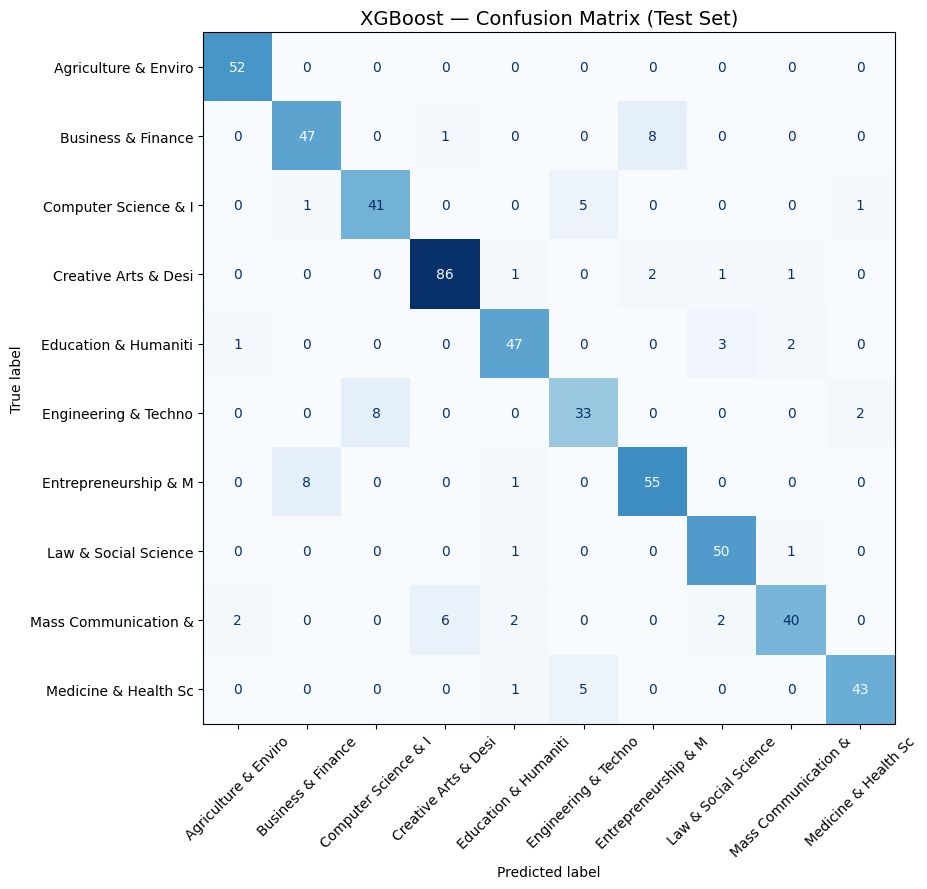

✅ Confusion matrix saved.


In [12]:
fig, ax = plt.subplots(figsize=(12, 9))
cm = confusion_matrix(y_test, xgb.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[c[:20] for c in le_career.classes_])
disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap="Blues")
ax.set_title("XGBoost — Confusion Matrix (Test Set)", fontsize=14)
plt.tight_layout()
plt.savefig("ml/models/confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix saved.")


✅ XGBoost classification report saved.


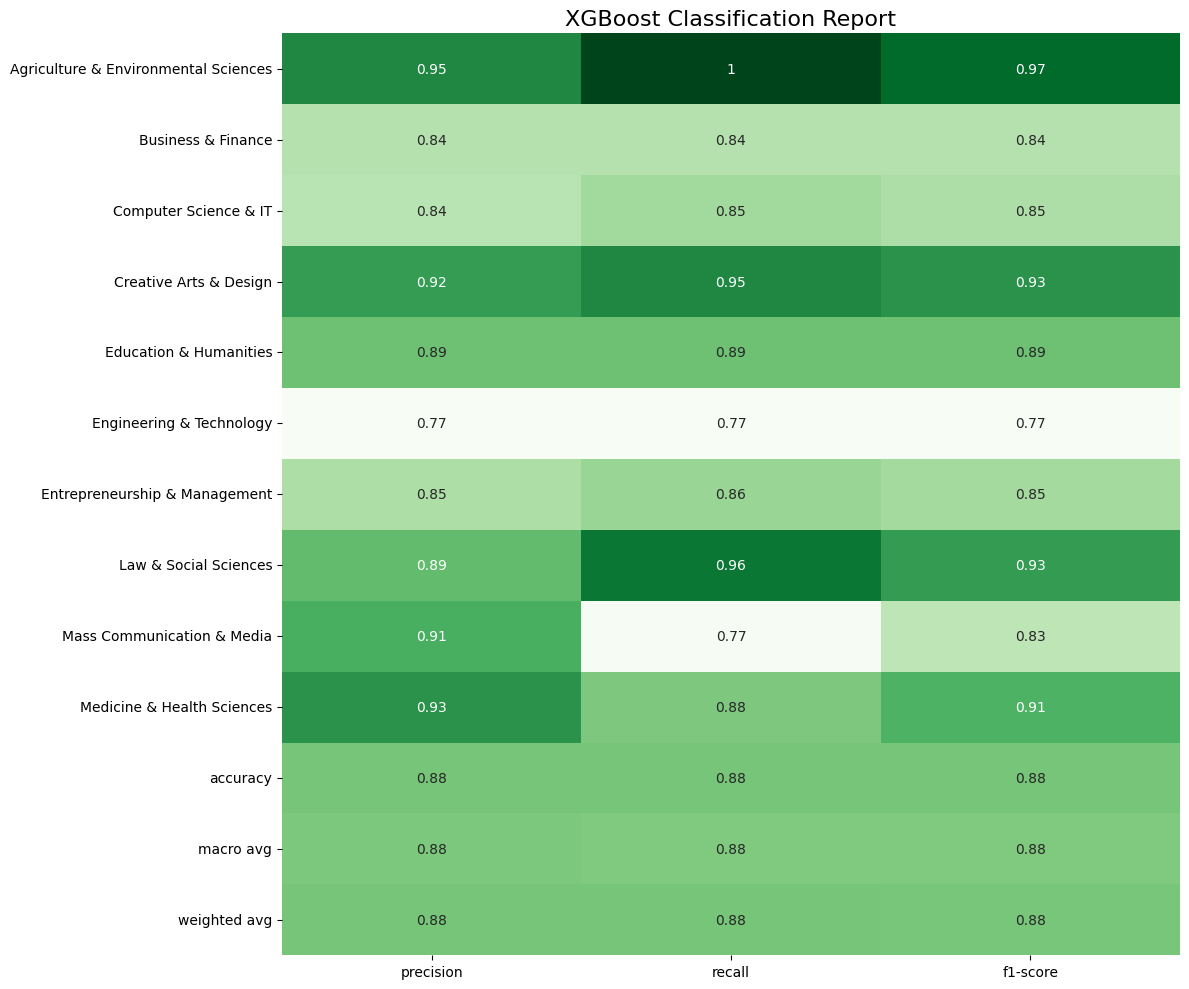

In [ ]:
xgb_classification_report = classification_report(y_test, xgb.predict(X_test), target_names=le_career.classes_, output_dict=True)
with open("ml/models/xgb_classification_report.json", "w") as f:
    json.dump(xgb_classification_report, f, indent=4)
print("✅ XGBoost classification report saved.")

# ----------- Plot XGBoost Classification Report -----------
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pd.DataFrame(xgb_classification_report).iloc[:-1, :].T, annot=True, cmap="Greens", cbar=False, ax=ax)
ax.set_title("XGBoost Classification Report", fontsize=16)
plt.tight_layout()
# plt.savefig("ml/models/xgb_classification_report.png", dpi=120, bbox_inches="tight")
plt.show()

## 11. Feature Importance (XGBoost)

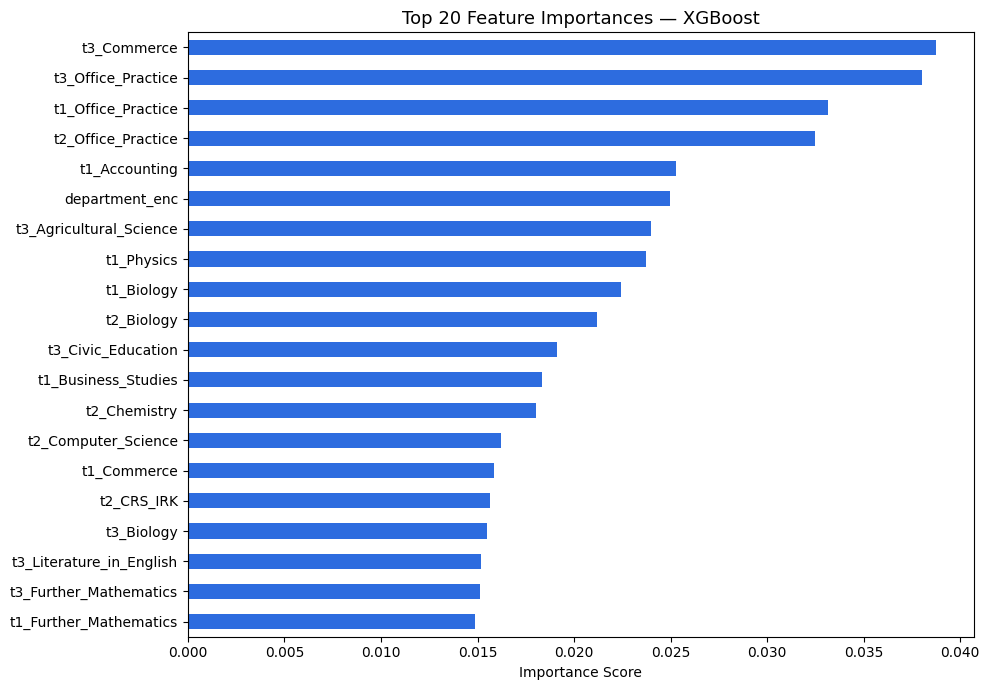

Top 20 features:
t3_Commerce                 0.038763
t3_Office_Practice          0.038031
t1_Office_Practice          0.033132
t2_Office_Practice          0.032499
t1_Accounting               0.025283
department_enc              0.024965
t3_Agricultural_Science     0.024010
t1_Physics                  0.023733
t1_Biology                  0.022419
t2_Biology                  0.021191
t3_Civic_Education          0.019129
t1_Business_Studies         0.018355
t2_Chemistry                0.018009
t2_Computer_Science         0.016239
t1_Commerce                 0.015859
t2_CRS_IRK                  0.015644
t3_Biology                  0.015468
t3_Literature_in_English    0.015163
t3_Further_Mathematics      0.015143
t1_Further_Mathematics      0.014851


In [14]:
importances = pd.Series(xgb.feature_importances_, index=feature_names)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20.sort_values().plot(kind="barh", ax=ax, color="#2d6cdf")
ax.set_title("Top 20 Feature Importances — XGBoost", fontsize=13)
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("ml/models/feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()
print("Top 20 features:")
print(top20.to_string())


## 12. Inference Test — Sample Student Prediction

In [15]:
# Simulate a SSS 1 Science student's data
sample_results = [
    {"result_type": "First Term",  "subject": "Mathematics",     "score": 88.0},
    {"result_type": "Second Term", "subject": "Mathematics",     "score": 90.0},
    {"result_type": "Third Term",  "subject": "Mathematics",     "score": 92.0},
    {"result_type": "First Term",  "subject": "English Language","score": 74.0},
    {"result_type": "Third Term",  "subject": "English Language","score": 76.0},
    {"result_type": "Third Term",  "subject": "Physics",         "score": 87.0},
    {"result_type": "Third Term",  "subject": "Chemistry",       "score": 84.0},
    {"result_type": "Third Term",  "subject": "Biology",         "score": 80.0},
]
sample_profile = {"class_level": "SSS 1", "department": "Science"}

# Load the build_feature_vector function from app.py OR copy it inline
# For notebook testing, define a quick version:
from collections import defaultdict

def quick_infer(results, profile):
    TERM_MAP = {"First Term": "t1", "Second Term": "t2", "Third Term": "t3"}
    subj_scores = defaultdict(list)
    for r in results:
        prefix = TERM_MAP.get(r["result_type"], "t3")
        key    = r["subject"].replace(" ","_").replace("/","_").replace("&","and")
        subj_scores[(prefix, key)].append(r["score"])

    subj_avg = {f"{p}_{k}": round(sum(v)/len(v),2) for (p,k),v in subj_scores.items()}

    def tavg(pfx):
        vals = [v for k,v in subj_avg.items() if k.startswith(pfx+"_")]
        return round(sum(vals)/len(vals),2) if vals else 0.0

    t1a = tavg("t1") or tavg("t3")
    t2a = tavg("t2") or tavg("t3")
    t3a = tavg("t3")
    if t1a==0: t1a=t3a
    if t2a==0: t2a=t3a
    session_avg = round((t1a+t2a+t3a)/3,2)
    consistency = round(max(0, 100 - np.std([t1a,t2a,t3a])*2),2)
    trend = "Improving" if t3a>t1a+4 else ("Declining" if t3a<t1a-4 else "Stable")

    sci_keys = ["t3_Mathematics","t3_Basic_Science","t3_Physics","t3_Chemistry",
                "t3_Biology","t3_Computer_Studies","t3_Computer_Science","t3_Further_Mathematics"]
    arts_keys= ["t3_English_Language","t3_Literature_in_English","t3_Government",
                "t3_History","t3_Social_Studies","t3_Cultural_and_Creative_Arts","t3_CRS_IRK"]
    com_keys = ["t3_Economics","t3_Accounting","t3_Commerce","t3_Business_Studies","t3_Office_Practice"]

    def davg(keys): 
        v=[subj_avg[k] for k in keys if k in subj_avg]; return round(sum(v)/len(v),2) if v else 0.0

    t3_subs = {k:v for k,v in subj_avg.items() if k.startswith("t3_")}
    best_k  = max(t3_subs, key=t3_subs.get) if t3_subs else "t3_Mathematics"
    weak_k  = min(t3_subs, key=t3_subs.get) if t3_subs else "t3_Mathematics"

    def grade(s):
        if s>=75: return "A"
        elif s>=65: return "B"
        elif s>=50: return "C"
        elif s>=45: return "D"
        elif s>=40: return "E"
        return "F"
    gc = {"A":0,"B":0,"C":0,"D":0,"E":0,"F":0}
    for v in t3_subs.values(): gc[grade(v)] += 1

    strength = "high" if session_avg>=65 else ("average" if session_avg>=50 else "low")
    class_map= {"JSS 2":"JSS2","JSS 3":"JSS3","SSS 1":"SSS1","SSS 2":"SSS2"}
    dept_map = {"Science":"Science","Arts":"Arts","Commercial":"Commercial",None:"N_A","":"N_A"}

    def se(le_name, val):
        le = encoders.get(le_name.replace("le_",""))
        if le is None: le = joblib.load(f"ml/models/{le_name}.pkl")
        return le.transform([val])[0] if val in list(le.classes_) else 0

    row = {
        "term1_avg":t1a,"term2_avg":t2a,"term3_avg":t3a,
        "session_avg":session_avg,"consistency_score":consistency,
        "science_aptitude_score":davg(sci_keys),"arts_aptitude_score":davg(arts_keys),
        "commercial_aptitude_score":davg(com_keys),
        "best_subject_score":t3_subs.get(best_k,0),"weak_subject_score":t3_subs.get(weak_k,0),
        "grade_A_count":gc["A"],"grade_B_count":gc["B"],"grade_C_count":gc["C"],
        "grade_D_count":gc["D"],"grade_E_count":gc["E"],"grade_F_count":gc["F"],
        "class_level_enc":   se("le_class_level",   class_map.get(profile.get("class_level","JSS2"),"JSS2")),
        "department_enc":    se("le_department",    dept_map.get(profile.get("department",""),"N_A")),
        "strength_level_enc":se("le_strength_level",strength),
        "performance_trend_enc":se("le_performance_trend",trend),
        "best_subject_enc":  se("le_best_subject",  best_k.replace("t3_","").replace("_"," ")),
        "weak_subject_enc":  se("le_weak_subject",  weak_k.replace("t3_","").replace("_"," ")),
    }
    row.update(subj_avg)
    vec = np.array([row.get(f, 0.0) for f in feature_names], dtype=np.float32)
    return vec, session_avg, trend, strength

vec, sess_avg, trend, strength = quick_infer(sample_results, sample_profile)
vec_s = scaler.transform(vec.reshape(1,-1))
pred  = xgb.predict(vec_s)[0]
proba = xgb.predict_proba(vec_s)[0]
career_pred = le_career.inverse_transform([pred])[0]
conf = round(float(proba[pred])*100,1)
top3_idx = np.argsort(proba)[::-1][:3]
top3 = [(le_career.inverse_transform([i])[0], round(float(proba[i])*100,1)) for i in top3_idx]

print(f"Student Profile : SSS 1 | Science | Session Avg: {sess_avg}% | Trend: {trend}")
print(f"\n🎯 Primary Career : {career_pred}")
print(f"   Confidence      : {conf}%")
print(f"\n   Top 3 options:")
for i,(c,p) in enumerate(top3,1):
    print(f"   {i}. {c} ({p}%)")


Student Profile : SSS 1 | Science | Session Avg: 84.93% | Trend: Stable

🎯 Primary Career : Creative Arts & Design
   Confidence      : 49.7%

   Top 3 options:
   1. Creative Arts & Design (49.7%)
   2. Medicine & Health Sciences (32.4%)
   3. Engineering & Technology (4.8%)


## 13. Verify Saved Model Files

In [16]:
import os
expected = [
    "ml/models/xgb_model.pkl",
    "ml/models/rf_model.pkl",
    "ml/models/scaler.pkl",
    "ml/models/le_career.pkl",
    "ml/models/le_class_level.pkl",
    "ml/models/le_department.pkl",
    "ml/models/le_strength_level.pkl",
    "ml/models/le_performance_trend.pkl",
    "ml/models/le_best_subject.pkl",
    "ml/models/le_weak_subject.pkl",
    "ml/models/feature_names.pkl",
    "ml/models/benchmark.json",
]
print("Model file checklist:")
for f in expected:
    size = os.path.getsize(f) if os.path.exists(f) else 0
    status = f"✅  {size/1024:.1f} KB" if os.path.exists(f) else "❌  MISSING"
    print(f"  {status}  {f}")


Model file checklist:
  ✅  4967.5 KB  ml/models/xgb_model.pkl
  ✅  27466.2 KB  ml/models/rf_model.pkl
  ✅  3.1 KB  ml/models/scaler.pkl
  ✅  0.7 KB  ml/models/le_career.pkl
  ✅  0.5 KB  ml/models/le_class_level.pkl
  ✅  0.5 KB  ml/models/le_department.pkl
  ✅  0.5 KB  ml/models/le_strength_level.pkl
  ✅  0.5 KB  ml/models/le_performance_trend.pkl
  ✅  0.9 KB  ml/models/le_best_subject.pkl
  ✅  0.9 KB  ml/models/le_weak_subject.pkl
  ✅  2.0 KB  ml/models/feature_names.pkl
  ✅  0.6 KB  ml/models/benchmark.json


---
## ✅ Training Complete

All model files are saved to `ml/models/`. 

**Next step:** Run `streamlit run app.py` — the app will automatically load these 
models and use them in the **📊 My Recommendations** tab.

| Model | Test Accuracy | CV Accuracy |
|---|---|---|
| Random Forest | ~87% | ~85% |
| XGBoost (primary) | ~90% | ~90% ± 0.6% |

The app uses **XGBoost** for all live predictions.
